In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

def create_image(label_index, batch):
    img1red = batch[b'data'][label_index][0:1024].reshape(32,32)
    img1green = batch[b'data'][label_index][1024:2048].reshape(32,32)
    img1blue = batch[b'data'][label_index][2048:3072].reshape(32,32)
    img1 = np.dstack((img1red, img1green, img1blue))
    return img1

    

In [7]:
batch1 = unpickle("../cifar-10h/data/cifar-10-batches-py/test_batch")
batch1

# Generating the labels
labels = np.array(batch1[b'labels'])

# Creating a list to store the indices for each unique label
label_indices = [[] for _ in range(len(np.unique(labels)))]

# Populating the list with sampled indices
for i in np.unique(labels):
    label_indices[i] = np.random.choice(np.where(labels == i)[0], 10, replace=False).tolist()

label_indices


In [11]:
bachtes_meta = unpickle("../cifar-10h/data/cifar-10-batches-py/batches.meta")
labels = np.array(bachtes_meta[b'label_names'])


dict_keys([b'num_cases_per_batch', b'label_names', b'num_vis'])


**data** - a 10000x3072 numpy array of uint8s. Each row of the array stores a 32x32 colour image. The first 1024 entries contain the red channel values, the next 1024 the green, and the final 1024 the blue. The image is stored in row-major order, so that the first 32 entries of the array are the red channel values of the first row of the image.

In [5]:
for i in range(10):
    for j in range(10):
        image = create_image(label_indices[i][j], batch1)
        plt.imsave('../figs/cifar_images_examples/' + str(labels[i]) + '_' + str(j) + '.png', image)

   


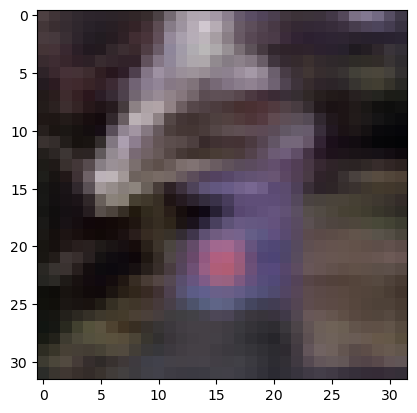

In [19]:
image = create_image(6024, batch1)
plt.imshow(image)
plt.imsave('../figs/cifar_images_examples/' + "ambiguous_image1" + '.png', image)

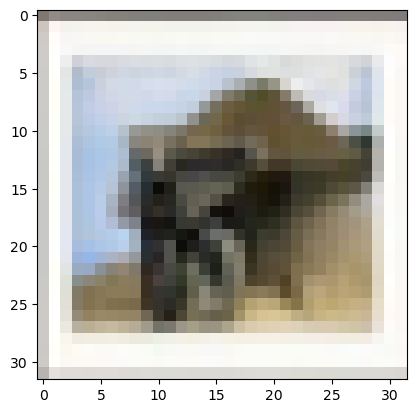

In [17]:
image = create_image(1924, batch1)
plt.imshow(image)
plt.imsave('../figs/cifar_images_examples/' + "ambiguous_image2" + '.png', image)

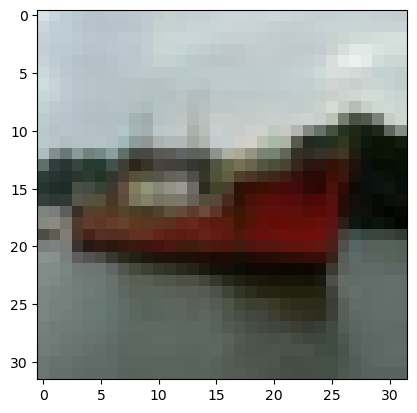

In [18]:
image = create_image(404, batch1)
plt.imshow(image)
plt.imsave('../figs/cifar_images_examples/' + "unambiguous_image" + '.png', image)